In [1]:
from quantile_network import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# import tables # Doesn't seem to want to import

## Data Processing

In [2]:
df_data = pd.read_json("data/ml_data.json").set_index('ievt_n')
df_data = df_data.dropna()
df_data

,Es,AoEs,E0,dt0,E1,dt1,E2,dt2,E3,dt3,Esum
ievt_n,,,,,,,,,,,
17,186.100067,0.841711,324.255313,1698.808083,186.484014,1691.245668,0.000000,0.000000,0.000000,0.000000,510.739327
49,2345.932129,0.843397,1005.035297,1938.264531,237.690102,1935.968861,213.292507,1940.195841,204.116879,1937.103902,2345.009424
56,804.222229,0.531521,358.809740,1779.081880,124.975914,1567.746659,96.162107,1573.089634,86.535131,1824.818342,804.326144
59,583.484985,0.661929,199.035527,1573.530460,196.086003,1543.404316,91.477276,1583.904015,58.570843,1586.748550,583.188122
64,950.647949,0.401381,341.170990,1832.540177,197.254448,1747.095643,138.970993,1792.237057,114.346371,1874.238776,952.117704
...,...,...,...,...,...,...,...,...,...,...,...
494833,727.849243,0.661129,481.852079,1605.528910,128.022535,1592.312940,117.454047,1580.992079,0.000000,0.000000,727.328660
494836,583.135620,0.526761,299.544853,1658.619872,113.385964,1597.337692,66.524266,1618.083701,46.721970,1604.726612,583.188122
494840,727.713196,0.675660,337.456100,1715.042397,181.195163,1679.221891,179.915047,1716.822330,28.762350,1716.803375,727.328660


In [3]:
xdata = df_data[['E1', 'E2', 'Esum', 'dt1', 'dt2']].to_numpy()
xdata

array([[ 186.48401404,    0.        ,  510.73932665, 1691.24566759,
           0.        ],
       [ 237.69010159,  213.29250697, 2345.0094238 , 1935.968861  ,
        1940.19584067],
       [ 124.97591431,   96.1621074 ,  804.32614374, 1567.74665925,
        1573.08963438],
       ...,
       [ 181.19516347,  179.91504678,  727.32866022, 1679.22189111,
        1716.82232952],
       [ 235.90388507,  130.82554513, 1500.70372776, 1545.89093424,
        1571.44775826],
       [ 175.66479192,  157.3532008 , 1273.40918695, 1664.93813817,
        1544.60356006]])

In [4]:
ydata = df_data[['Es', 'AoEs']].to_numpy()
ydata

array([[1.86100067e+02, 8.41710687e-01],
       [2.34593213e+03, 8.43396664e-01],
       [8.04222229e+02, 5.31520903e-01],
       ...,
       [7.27713196e+02, 6.75660074e-01],
       [1.50171143e+03, 6.82960868e-01],
       [1.25080762e+03, 4.20953572e-01]])

In [5]:
train_in = xdata
train_out = ydata

In [6]:
train_in

array([[ 186.48401404,    0.        ,  510.73932665, 1691.24566759,
           0.        ],
       [ 237.69010159,  213.29250697, 2345.0094238 , 1935.968861  ,
        1940.19584067],
       [ 124.97591431,   96.1621074 ,  804.32614374, 1567.74665925,
        1573.08963438],
       ...,
       [ 181.19516347,  179.91504678,  727.32866022, 1679.22189111,
        1716.82232952],
       [ 235.90388507,  130.82554513, 1500.70372776, 1545.89093424,
        1571.44775826],
       [ 175.66479192,  157.3532008 , 1273.40918695, 1664.93813817,
        1544.60356006]])

In [7]:
train_out

array([[1.86100067e+02, 8.41710687e-01],
       [2.34593213e+03, 8.43396664e-01],
       [8.04222229e+02, 5.31520903e-01],
       ...,
       [7.27713196e+02, 6.75660074e-01],
       [1.50171143e+03, 6.82960868e-01],
       [1.25080762e+03, 4.20953572e-01]])

Text(0.5, 0, 'train_in[2] == Esum (normalised)')

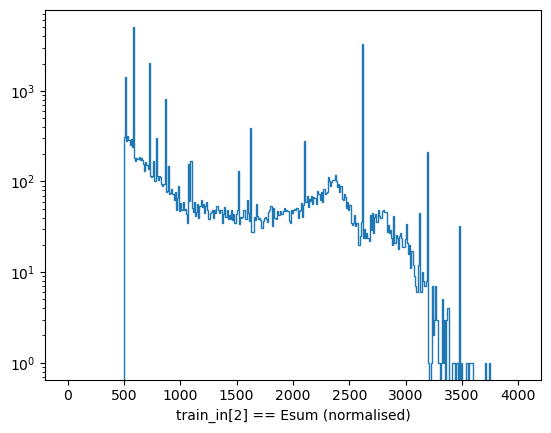

In [8]:
plt.figure()

_ = plt.hist(
    train_in[:, 2], range=(0,4000), bins=400, histtype='step'
)
plt.yscale('log')
plt.xlabel('train_in[2] == Esum (normalised)')


In [9]:
## Do a test train split
train_in_split, test_in, train_out_split, test_out = train_test_split(
    train_in,
    train_out,
    test_size=1/3,
    random_state=42
)

In [10]:
len(xdata), len(train_in), len(train_in_split), len(test_in) 

(30464, 30464, 20309, 10155)

In [11]:
# normalise output
input_dims  = len(train_in.T)
output_dims = len(train_out.T)

norm_info_in =[[0,1] for i in range(input_dims)]  # µ and stdev
norm_info_out=[[0,1] for i in range(output_dims)] # µ and stdev

train_in_norm = train_in_split.copy()
train_out_norm = train_out_split.copy()
test_in_norm = test_in.copy()
test_out_norm = test_out.copy()

for x in range(input_dims):
    norm_info_in[x] = [np.mean(train_in_split[:,x]), np.std(train_in_split[:,x])]
    train_in_norm[:,x]=(train_in_split[:,x]-np.mean(train_in_split[:,x]))/(np.std(train_in_split[:,x]))
    test_in_norm[:,x]=(test_in[:,x]-np.mean(train_in_split[:,x]))/(np.std(train_in_split[:,x]))

for x in range(output_dims):
    norm_info_out[x] = [np.mean(train_out_split[:,x]), np.std(train_out_split[:,x])]
    train_out_norm[:,x]=(train_out_split[:,x]-np.mean(train_out_split[:,x]))/(np.std(train_out_split[:,x]))
    test_out_norm[:,x]=(test_out[:,x]-np.mean(train_out_split[:,x]))/(np.std(train_out_split[:,x]))

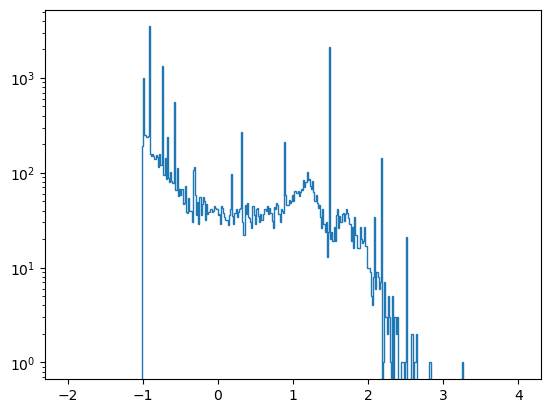

In [12]:
plt.figure()

_ = plt.hist(
    train_in_norm[:, 2], range=(-2,4), bins=400, histtype='step'
)
plt.yscale('log')


In [13]:
x_val, y_val = make_dataset(
    train_in_norm,          # input x
    train_out_norm,         # input y
    input_dims,             # x dims
    output_dims,            # y dims
    train_in_norm.shape[0]  # number of samples
) # examples


In [14]:
print(x_val.shape, y_val.shape)

(40618, 8) (40618, 1)


In [14]:
# in out case x_val should be twice as long a out training data
len(train_in_norm), len(x_val)

(20309, 40618)

In [15]:
x_val

array([[ 0.05563559, -1.27038457, -0.84898493, ...,  1.        ,
         0.        ,  0.        ],
       [-0.28121572,  0.3907929 ,  0.45738033, ...,  1.        ,
         0.        ,  0.        ],
       [-0.55249182, -1.19258203, -0.99850893, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.04349683, -1.27038457, -0.90800808, ...,  0.        ,
         1.        , -0.84099428],
       [ 0.26705538, -0.34529801,  0.31686816, ...,  0.        ,
         1.        ,  0.38172007],
       [ 0.86797585,  0.29683718, -0.18841484, ...,  0.        ,
         1.        , -0.1234926 ]])

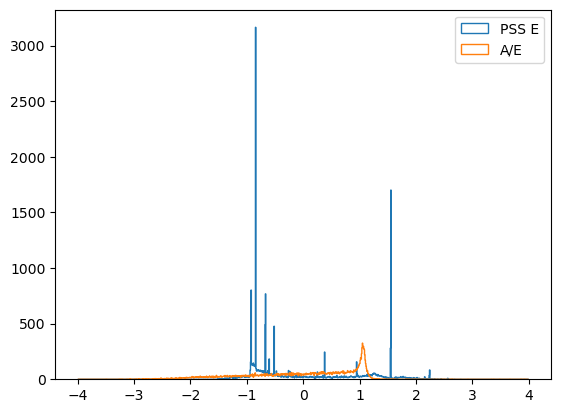

In [16]:
plt.figure()

_ = plt.hist(
    y_val[:len(train_in_norm)], range=(-4, 4), bins=1000, histtype='step', label='PSS E'
)
_ = plt.hist(
    y_val[len(train_in_norm):], range=(-4, 4), bins=1000, histtype='step', label='A/E'
)
plt.legend()

## Define the Model

Parameters to choose: (defaults taken from paper)
> hidden:    default=5,     Number of hidden layers   
> width:     default=50,    Width of the hidden layers  
> alpha:     default=0.2,   Slope for leaky relu  
> initialLR: default=0.001, Initial learning rate  
> batch:     default=512,   Batch size  
> cycles:    default=4,     Number of cylces to train for  
> epochs:    default=100,   Number of epochs in a cylce  
> patience:  default=100,   Number of epochs with no improvement before ending  

In [21]:
width       = 50
hidden      = 5
patience    = 100
cycles      = 4
initiallr   = 0.001
epochs      = 100
batch       = 512
normalise   = True
layer_output_dims = 5 if normalise else 1


In [22]:
if normalise:
    model = QuantileNet(network_type="normalizing")
else:
    model = QuantileNet(network_type="no normalizing")

model.add(
    tf.keras.layers.Dense(
        width,
        kernel_initializer="glorot_uniform",
        activation=None
    )
)
model.add(tf.keras.layers.LeakyReLU())#alpha=alpha))

for n in range(hidden - 1):
    model.add(
        tf.keras.layers.Dense(
            width,
            kernel_initializer="glorot_uniform",
            activation=None
        )
    )
    model.add(tf.keras.layers.LeakyReLU())#alpha=alpha))

model.add(
    tf.keras.layers.Dense(
        layer_output_dims,
        kernel_initializer="glorot_uniform",
        activation=None
    )
)

In [23]:
## Do another test train split for validation data
iqn_train_in, iqn_val_in, iqn_train_out, iqn_val_out = train_test_split(
    x_val,
    y_val,
    test_size=1/10,
    random_state=42
)

callbackMetric="val_loss"

callback = tf.keras.callbacks.EarlyStopping(
    monitor=callbackMetric,
    patience=patience,
    restore_best_weights=True
)

iqn_train_out = tf.expand_dims(iqn_train_out,1)
iqn_val_out = tf.expand_dims(iqn_val_out,1)

In [24]:
epoch_list=[]
train_loss_list=[]
val_loss_list=[]

for x in range(cycles):
    
    model.compile(
        # optimizer=tf.keras.optimizers.Adam(
        optimizer=tf.keras.optimizers.legacy.Adam(
            initiallr * (10**(-x)),
            amsgrad=False
        ),
        loss=model.loss,
        run_eagerly=False
    )

    history = model.fit(
        iqn_train_in,
        iqn_train_out,
        validation_data=(
            iqn_val_in,
            iqn_val_out
        ),
        epochs      = epochs,
        batch_size  = batch,
        verbose     = 2,
        callbacks   = [callback] #, callback2])
    )
    
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epoch_list.append(len(train_loss))
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    #Save the network
    model.save('emulator.keras')

epoch_list = range(1,sum(epoch_list)+1)
train_loss = np.concatenate(train_loss_list, axis=0)
val_loss = np.concatenate(val_loss_list, axis=0)

Epoch 1/100
72/72 - 4s - loss: 0.6507 - val_loss: 0.4133 - 4s/epoch - 55ms/step
Epoch 2/100
72/72 - 1s - loss: 0.3408 - val_loss: 0.3101 - 1s/epoch - 15ms/step
Epoch 3/100
72/72 - 2s - loss: 0.2985 - val_loss: 0.2996 - 2s/epoch - 22ms/step
Epoch 4/100
72/72 - 1s - loss: 0.2931 - val_loss: 0.3084 - 1s/epoch - 20ms/step
Epoch 5/100
72/72 - 1s - loss: 0.2932 - val_loss: 0.2791 - 1s/epoch - 18ms/step
Epoch 6/100
72/72 - 1s - loss: 0.2841 - val_loss: 0.2861 - 1s/epoch - 18ms/step
Epoch 7/100
72/72 - 2s - loss: 0.2885 - val_loss: 0.2917 - 2s/epoch - 25ms/step
Epoch 8/100
72/72 - 3s - loss: 0.2858 - val_loss: 0.2983 - 3s/epoch - 38ms/step
Epoch 9/100
72/72 - 2s - loss: 0.2922 - val_loss: 0.2865 - 2s/epoch - 21ms/step
Epoch 10/100
72/72 - 3s - loss: 0.2803 - val_loss: 0.2849 - 3s/epoch - 42ms/step
Epoch 11/100
72/72 - 2s - loss: 0.2833 - val_loss: 0.2921 - 2s/epoch - 34ms/step
Epoch 12/100
72/72 - 3s - loss: 0.2893 - val_loss: 0.2947 - 3s/epoch - 36ms/step
Epoch 13/100
72/72 - 6s - loss: 0.284

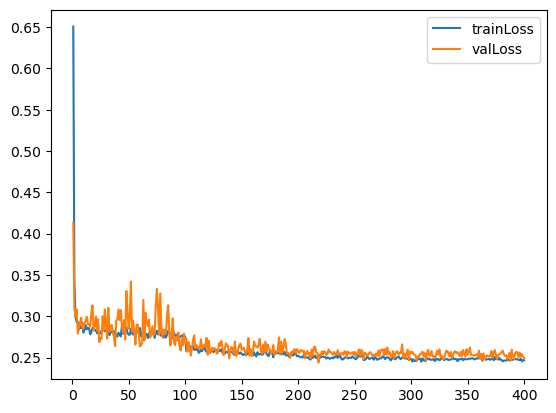

In [25]:
plt.figure()
plt.plot(epoch_list[:], train_loss[:], label="trainLoss")
plt.plot(epoch_list[:], val_loss[:], label="valLoss")
plt.legend()
# plt.savefig(networkname+"_loss_curve.png")

## Evaluate the trained model

In [ ]:
x = [test_out_norm[:,0]]
y = [test_out_norm[:,1]]

# Make the correct input data for the IQN
in_val     = np.zeros(shape=np.array(x).shape)
test_data_set_y = np.concatenate([test_in_norm.T, in_val+1, in_val,   in_val, x], axis=0)
test_data_set_x = np.concatenate([test_in_norm.T, in_val,   in_val+1, x,      y], axis=0)
test_data_set  = np.concatenate([test_data_set_x, test_data_set_y], axis=1)


iqn_test_in = test_data_set[:-1,:].T
iqn_test_out = np.expand_dims(test_data_set[-1,:],1)

In [17]:
iqn_test_in.shape

(20310, 8)

In [27]:
model.evaluate(iqn_test_in, iqn_test_out, verbose=2, batch_size=128) #131072)

159/159 - 4s - loss: 0.2502 - 4s/epoch - 23ms/step


0.25022652745246887

## Start Sampling from the trained IQN

In [28]:
new_train_in = xdata.copy()
new_train_out = ydata.copy()

# new_train_out=(new_train_out+10)/(new_train_in+10) # not possible with different input and output dims

new_norm_info_in  = [[0,1] for i in range(input_dims)]
new_norm_info_out = [[0,1] for i in range(output_dims)]
new_train_in, new_test_in, new_train_out, new_test_out = train_test_split(
    new_train_in,
    new_train_out,
    test_size=1/3,
    random_state=42
)

new_test_in_norm = new_test_in.copy()
#Normalization 
for x in range(input_dims):
    new_norm_info_in[x]=[np.mean(new_train_in[:,x]),np.std(new_train_in[:,x])]
    new_test_in_norm[:,x]=(new_test_in[:,x]-np.mean(new_train_in[:,x]))/(np.std(new_train_in[:,x]))

for x in range(output_dims):
    new_norm_info_out[x]=[np.mean(new_train_out[:,x]),np.std(new_train_out[:,x])]

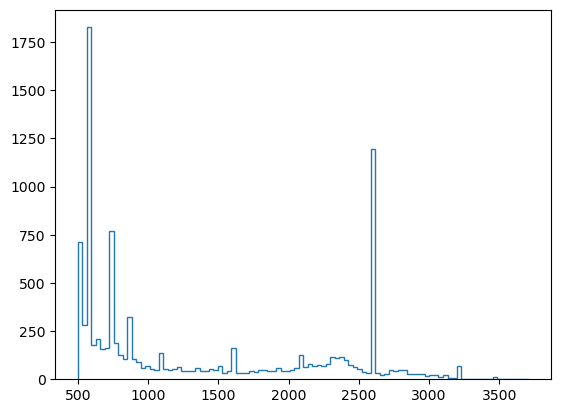

In [29]:
plt.figure()

_ = plt.hist(new_test_in[:,2], bins=100, histtype='step')


In [30]:
sample_num=1000
batch_size = 1000
ROW_SIZE = test_in_norm.shape[0]
NUM_COLUMNS = sample_num*output_dims

# The following is good for really large datasets but I can't get it
# to work on my computer
'''filename = 'emulator.h5'
f = tables.open_file(filename, mode='w')
atom = tables.Float32Atom()
all_data = f.create_earray(f.root, 'data', atom, (0, NUM_COLUMNS))'''

all_data = pd.DataFrame(columns=[f'col_{i}' for i in range(NUM_COLUMNS)], dtype=np.float32)
input_data = []

In [31]:
for y in range(0, new_test_in_norm.shape[0], batch_size):

    current_test_in = new_test_in_norm[y:min(y+batch_size, test_in.shape[0]),:]
    current_test_in = tf.transpose(current_test_in)
    current_test_in = tf.cast(current_test_in, tf.float32)

    out = sample_net(
        model, #Network
        sample_num, #Number of samples
        current_test_in, #Input
        current_test_in.shape[1], #Number of examples (batch size)
        current_test_in.shape[0], #5d input
        output_dims, #2d output
        network_type="not normalizing"
    ) 
    out = np.array(out)
    
    current_test_in = np.array(current_test_in).T

    for x in range(output_dims):
        out[:,:,x] = out[:,:,x]*norm_info_out[x][1]+norm_info_out[x][0]
        current_test_in[:,x] = current_test_in[:,x]*norm_info_in[x][1]+norm_info_in[x][0]

    input_data.append(new_test_in[y:min(y+batch_size, test_in.shape[0]),2])
    out = out.reshape(out.shape[0], out.shape[1]*out.shape[2])

    out_df = pd.DataFrame(out, columns=[f'col_{i}' for i in range(out.shape[1])])
    # print(out_df.shape)
    all_data = pd.concat([all_data, out_df], ignore_index=True)

    percent_done=min(y+batch_size, test_in_norm.shape[0])*100/test_in_norm.shape[0]
    percent_done=round(percent_done,4)

    print("Processing is " + str(percent_done)+"% done")

Processing is 9.8474% done
Processing is 19.6947% done
Processing is 29.5421% done
Processing is 39.3895% done
Processing is 49.2368% done
Processing is 59.0842% done
Processing is 68.9316% done
Processing is 78.7789% done
Processing is 88.6263% done
Processing is 98.4737% done
Processing is 100.0% done


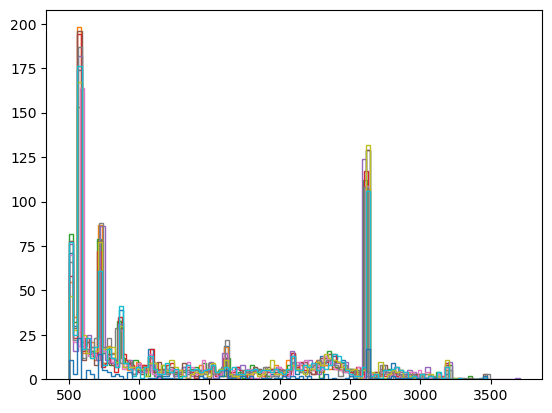

In [32]:
plt.figure()

for i in range(len(input_data)):
    _ = plt.hist(input_data[i], bins=100, histtype='step')


In [33]:
all_data

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_1990,col_1991,col_1992,col_1993,col_1994,col_1995,col_1996,col_1997,col_1998,col_1999
0,-2668.836426,0.738093,-2051.189453,0.846572,1817.991455,0.418302,-3445.889648,1.106419,-2339.679199,0.397130,...,859.131348,0.016512,-305.846069,0.300291,1015.866272,0.958375,-782.429077,0.483575,-5442.342285,1.358567
1,296.249390,0.140823,-941.789429,0.615074,-663.200317,0.528596,-540.734863,0.069959,42.729370,-0.103608,...,-671.252686,0.914061,-650.780273,0.590727,-1508.329712,0.927060,-1572.644897,0.762040,-56.495361,0.389260
2,579.321777,0.174816,-68.819580,-0.122991,-1735.220093,0.536539,-13.147705,0.643932,-2516.450195,0.699505,...,-5574.858398,0.922601,-1940.099243,0.685130,-1712.089233,0.149429,-430.751099,-0.324494,-4883.510742,0.685556
3,118.110596,-0.415287,-3113.474609,1.337643,-5028.890625,1.219380,363.309143,0.423148,476.453369,0.724847,...,-540.456421,0.058826,352.162964,0.634805,-1609.562134,-0.038644,-1610.040649,0.081100,-3140.645508,0.954383
4,-1463.762817,-0.151263,-1961.784302,0.913007,508.989807,0.843594,-1746.893921,-0.089088,-778.473511,-0.102594,...,-1083.852173,-0.217384,-1601.576538,0.396849,727.982788,-0.035709,-707.745605,0.748912,-1730.827271,0.144772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10150,-5714.516602,1.360863,-946.616821,0.858968,-2205.772461,0.596449,-1435.248901,0.879789,-1218.446411,0.134960,...,-1149.492310,0.634553,-3182.938965,0.856295,-1433.663696,0.623430,-109.833496,-0.366846,-4541.719727,1.059377
10151,-1050.548218,0.816120,-969.027222,0.797119,-574.006470,0.445850,-315.772705,0.505533,-523.326660,0.547154,...,247.718506,0.616937,-52.867188,0.612904,-1018.517700,0.870278,-673.859253,0.857157,-1240.109497,0.894340
10152,-2131.377441,0.470616,-533.608276,0.850981,-3698.453125,0.162799,-627.779175,0.124725,-3808.644531,0.264333,...,-5852.148926,0.898263,-1985.284546,-0.166498,-1574.518433,0.576867,-986.401001,-0.158438,-5377.602539,1.101369
10153,-2248.119629,0.504806,-902.113403,0.314229,-2937.641602,0.619250,-2447.960938,0.322270,-1400.540405,0.496457,...,-1735.921997,0.545446,-2551.162598,0.266429,87.997681,0.723136,-708.542969,0.869142,-1553.121948,0.069660


In [34]:
len(test_out)

10155

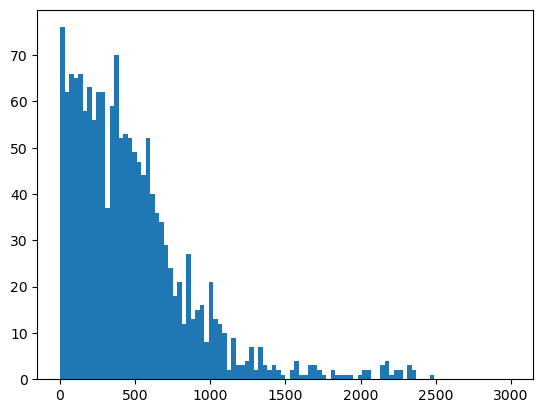

In [35]:
plt.figure()

_ = plt.hist(all_data.col_1990, range=(0,3000), bins=100)

In [62]:
input_data[2][0], input_data[1][0]

(583.1881220276, 1620.7313473885)

In [76]:
fep_vals = []
nfep = 0
dep_vals = []
ndep = 0
sep_vals = []
nsep = 0
for i in range(len(input_data)):
    for j in range(len(input_data[i])):
        index = i*1000 + j
        E = input_data[i][j]

        E_diff_fep = E - 2615
        E_diff_dep = E - 2615 + 1022
        E_diff_sep = E - 2615 + 511

        if abs(E_diff_fep) < 5 :
            nfep += 1
            for k, col in enumerate(all_data.columns):
                if k % 2:
                    val = all_data[col].loc[index]
                    fep_vals.append(val)
        
        if abs(E_diff_dep) < 5 :
            ndep += 1
            for k, col in enumerate(all_data.columns):
                if k % 2:
                    val = all_data[col].loc[index]
                    dep_vals.append(val)

        if abs(E_diff_sep) < 5 :
            nsep += 1
            for k, col in enumerate(all_data.columns):
                if k % 2:
                    val = all_data[col].loc[index]
                    sep_vals.append(val)

Text(0, 0.5, 'pdf')

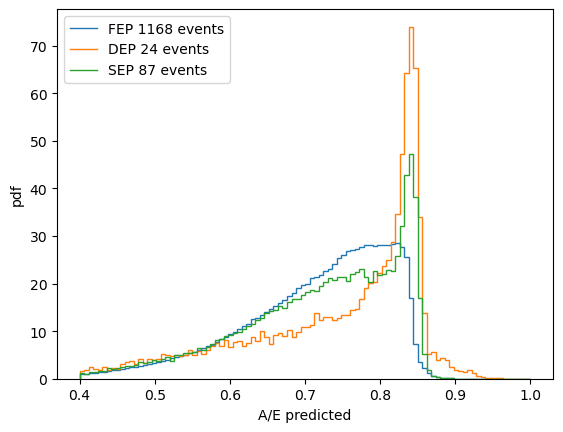

In [77]:
plt.figure()

freq, bin_edges = np.histogram(fep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/nfep, bin_edges, label=f'FEP {nfep} events')

freq, bin_edges = np.histogram(dep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/ndep, bin_edges, label=f'DEP {ndep} events')

freq, bin_edges = np.histogram(sep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/nsep, bin_edges, label=f'SEP {nsep} events')

plt.legend()

# plt.yscale('log')
plt.xlabel('A/E predicted')
plt.ylabel('pdf')

Text(0, 0.5, 'pdf')

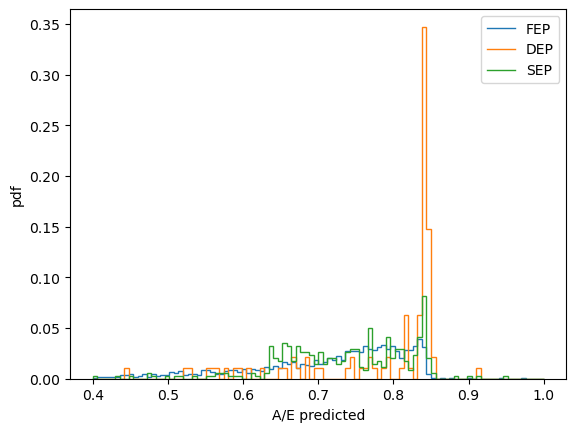

In [82]:
plt.figure()

all_fep_vals = []
all_dep_vals = []
all_sep_vals = []
for i in range(len(train_in)):
    E_true = train_in[i][2]
    AoE = train_out[i][1]
    E_diff = E_true - 2615
    if abs(E_diff) < 10:
        all_fep_vals.append(AoE)

    E_diff = E_true - 2615 + 511 + 511
    if abs(E_diff) < 10:
        all_dep_vals.append(AoE)

    E_diff = E_true - 2615 + 511
    if abs(E_diff) < 10:
        all_sep_vals.append(AoE)

freq, bin_edges = np.histogram(all_fep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/sum(freq), bin_edges, label='FEP')
freq, bin_edges = np.histogram(all_dep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/sum(freq), bin_edges, label='DEP')
freq, bin_edges = np.histogram(all_sep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/sum(freq), bin_edges, label='SEP')

plt.legend()

# plt.yscale('log')
plt.xlabel('A/E predicted')
plt.ylabel('pdf')

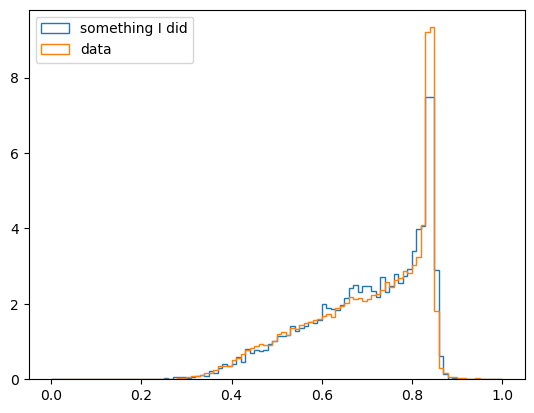

In [34]:
plt.figure()

_ = plt.hist(all_data.col_1991, range=(0,1), bins=100, histtype='step', density=True, label='something I did')
_ = plt.hist(df_data.AoEs, range=(0,1), bins=100, histtype='step', density=True, label='data')

plt.legend()

In [36]:
_, data, _, _ = train_test_split(df_data, df_data,test_size=1/3, random_state=42)

def calc_quant(data, vals):
    n = data.shape[1]
    left = np.count_nonzero(vals < data, axis=1)
    right = np.count_nonzero(vals <= data, axis=1)
    pct = (right + left + np.where(right>left, 1+0*right, 0*right)) /(2*n)
    return pct

batch_size=5000
num_samples = 1000
bins=100

In [37]:
columns = ['Column1', 'Column2']

# Create DataFrames
median_prediction_df = pd.DataFrame(columns=columns)
mean_prediction_df = pd.DataFrame(columns=columns)
gen_quantile_df = pd.DataFrame(columns=columns)

total_samples = data.shape[0]
for x in range(total_samples//batch_size+1):
    actual_batch_size = min((x+1)*batch_size, total_samples)- x*batch_size
    
    # Extract the batch from the DataFrame
    batch_data = all_data.iloc[x*batch_size:min((x + 1) * batch_size, total_samples)]

    # Convert DataFrame to NumPy array
    data_array = batch_data.to_numpy()

    reshaped_array = data_array.reshape(data_array.shape[0]*data_array.shape[1]//output_dims, output_dims)

    # true_data = df_data[['Es', 'AoEs']].iloc[x*batch_size:min((x+1)*batch_size, total_samples)].to_numpy()
    true_data = new_test_out[x*batch_size:min((x + 1) * batch_size, total_samples), :]
    
    reshaped_data = reshaped_array.reshape(
        (reshaped_array.shape[0]//actual_batch_size, actual_batch_size, output_dims),
        order="f"
    )

    all_quants = []
    all_means = []
    all_medians = []

    for y in range(output_dims):
        true_val = reshaped_data[:,:,y].T
        pred_val = true_data[:,y:y+1] # This order is in the file - not sure why they are named this way
        # pred_val = reshaped_data[:,:,y].T
        # true_val = true_data[:,y:y+1]
        quants = calc_quant(true_val, pred_val)
        medians = np.median(reshaped_data[:,:,y], axis=0)
        means = np.mean(reshaped_data[:,:,y], axis=0)

        all_quants.append(np.expand_dims(quants, axis=1))
        all_medians.append(np.expand_dims(medians, axis=1))
        all_means.append(np.expand_dims(means, axis=1))

    all_quants_df = pd.DataFrame(np.concatenate(all_quants, axis=1), columns=columns)
    all_medians_df = pd.DataFrame(np.concatenate(all_medians, axis=1), columns=columns)
    all_means_df = pd.DataFrame(np.concatenate(all_means, axis=1), columns=columns)

    median_prediction_df = pd.concat([median_prediction_df, all_medians_df], ignore_index=True)
    mean_prediction_df = pd.concat([mean_prediction_df, all_means_df], ignore_index=True)
    gen_quantile_df = pd.concat([gen_quantile_df, all_quants_df], ignore_index=True) 
    
    print(str(100*min((x+1)*batch_size, total_samples)/total_samples)+"% done")

/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_86704/1547022445.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  median_prediction_df = pd.concat([median_prediction_df, all_medians_df], ignore_index=True)
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_86704/1547022445.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mean_prediction_df = pd.concat([mean_prediction_df, all_means_df], ignore_index=True)
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_86704

49.23682914820286% done
98.47365829640572% done
100.0% done


(array([11., 21., 14., 15., 17., 23., 18., 10., 17.,  9.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

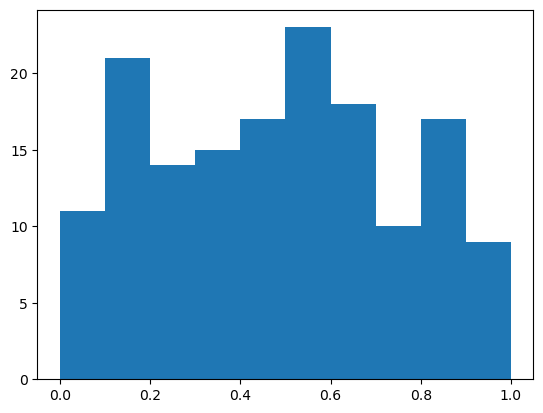

In [38]:
plt.hist(calc_quant(true_val, pred_val))

In [39]:
weights = np.where(np.isnan(median_prediction_df), 0, 1) # 
medians = np.where(np.isnan(median_prediction_df), 0, median_prediction_df)
absolute_error_medians = new_test_out-medians
error_medians = absolute_error_medians/new_test_out

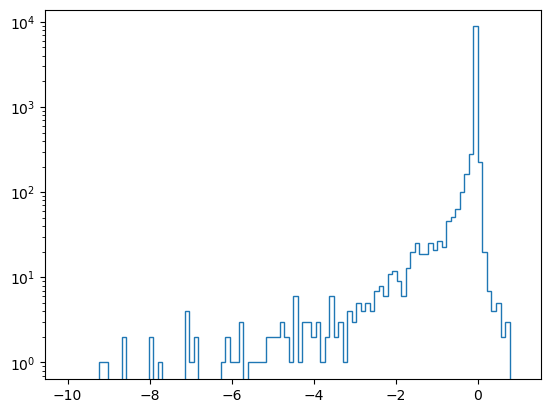

In [40]:
plt.figure()
plt.hist(error_medians[:,0], range=(-10,1), bins=100, histtype='step')
plt.yscale('log')


In [41]:
all_counts=[]
all_edges=[]
quant_counts=[]
quant_edges=[]
total_counts = 0
bins=50

ranges= [[0,3000],[0,1]]

for x in range(total_samples//batch_size+1):

    pred_counts=[]
    actual_batch_size = min((x+1)*batch_size, total_samples)- x*batch_size

    # recoData = f.root.recoData[x*batch_size:min((x+1)*batch_size, total_samples),:]
    #rawRecoData =f.root.rawRecoData[x*batch_size:min((x+1)*batch_size, total_samples),:]
    #predData = f.root.data[x*batch_size:min((x+1)*batch_size, total_samples),:]
    #genData = f.root.genData[x*batch_size:min((x+1)*batch_size, total_samples),:]
    temp_ydata = ydata[x*batch_size:min((x+1)*batch_size, total_samples),:]
    pred_data = all_data.to_numpy()[x*batch_size:min((x+1)*batch_size, total_samples),:]
    temp_xdata = xdata[x*batch_size:min((x+1)*batch_size, total_samples),:]
    
    quants = gen_quantile_df.to_numpy()[x*batch_size:min((x+1)*batch_size, total_samples),:]
    weights = np.ones(temp_xdata[:,0].shape)
    total_counts+=np.sum(weights)

    for z in range(num_samples):
        current_data = pred_data[:,output_dims*z:output_dims*(z+1)]
        temp = []
        for y in range(output_dims):
            counts, _ = np.histogram(current_data[:,y], range=ranges[y], bins=bins, weights=weights)
            temp.append(counts)
        pred_counts.append(temp)
    pred_counts = np.array(pred_counts)

    for y in range(output_dims):
        #reco_counts, edges = np.histogram(recoData[:,y], range=ranges[y], bins=bins, weights=weights)
        true_counts, edges = np.histogram(temp_ydata[:,y], range=ranges[y], bins=bins, weights=weights)
        edges = edges[1:]/2+edges[:-1]/2
        q_counts, q_edges = np.histogram(quants[:,y], range=(0,1), bins=bins, weights=weights)
        q_edges = q_edges[1:]

        if(x==0):
            # all_counts.append([reco_counts, pred_counts[:,y,:], gen_counts])
            all_counts.append([pred_counts[:,y,:], true_counts])
            all_edges.append(edges)
            quant_counts.append([q_counts])
            quant_edges.append(q_edges)
        else:
            # all_counts[y][0]+=reco_counts
            all_counts[y][0]+=pred_counts[:,y,:]
            all_counts[y][1]+=true_counts
            quant_counts[y] +=q_counts

print("Total counts", total_counts)    
print("Total samples", total_samples) 

Total counts 10155.0
Total samples 10155


In [42]:
q_counts

array([6., 0., 2., 2., 1., 2., 4., 6., 3., 6., 1., 5., 0., 3., 5., 2., 2.,
       3., 6., 2., 2., 3., 8., 3., 1., 5., 2., 5., 6., 5., 4., 3., 4., 2.,
       5., 3., 2., 2., 2., 1., 2., 2., 2., 7., 4., 2., 2., 2., 1., 2.])

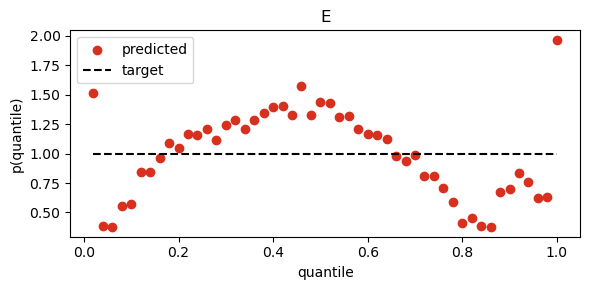

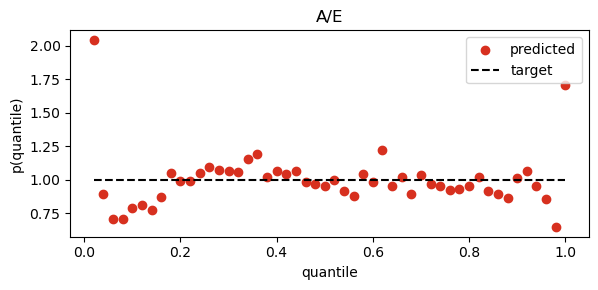

In [43]:
labels=["E", "A/E"]
titles=["E", "A/E"]
for x in range(output_dims):
    q_sums = [quant_counts[x][0,0]]
    for y in range(1, len(q_counts)):
        q_sums.append(q_sums[-1]+quant_counts[x][0,y])
    fig, (ax1) = plt.subplots(1, 1, figsize=(6,3))#, gridspec_kw={'height_ratios': [0.5, 1]})
    ax1.scatter(q_edges, bins*quant_counts[x][0,:]/np.sum(quant_counts[x][0,:]), c="#d7301f", label="predicted")
    ax1.plot(q_edges, q_edges*0+1, c="k", linestyle="--", label="target")
    # ax1.set_ylim((0.7,1.3))
    ax1.set_ylabel("p(quantile)")
    ax1.set_xlabel("quantile")
    ax1.set_title(labels[x])
    ax1.legend()
    plt.tight_layout()
    fig.subplots_adjust(wspace=0.0, hspace=0.1)

In [44]:
pred50 = []
pred16 = []
pred84 = []
for x in range(output_dims):
    pred50.append(np.quantile(all_counts[x][0], 0.5, axis=0))
    pred16.append(np.quantile(all_counts[x][0], 0.16, axis=0))
    pred84.append(np.quantile(all_counts[x][0], 0.84, axis=0))

/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_86704/985581516.py:15: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(all_edges[x], all_counts[x][1]/all_counts[x][1], color="k", marker="o",facecolors="none", s=5, linewidth=0.5)
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_86704/985581516.py:17: RuntimeWarning: divide by zero encountered in divide
  all_edges[x], pred50[x]/all_counts[x][1],
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_86704/985581516.py:17: RuntimeWarning: invalid value encountered in divide
  all_edges[x], pred50[x]/all_counts[x][1],
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_86704/985581516.py:18: RuntimeWarning: divide by zero encountered in divide
  xerr=0, yerr=[pred50[x]/all_counts[x][1]- pred16[x]/all_counts[x][1], pred84[x]/all_counts[x][1]-pred50[x]/all_counts[x][1]],
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_86704/985581516.py:18: RuntimeWarning: invalid value encountere

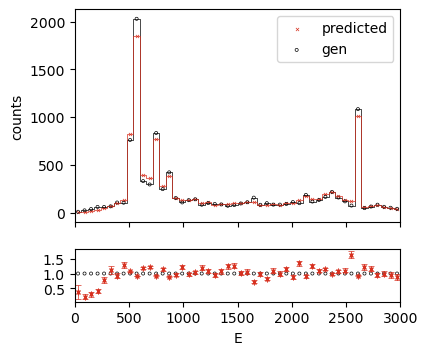

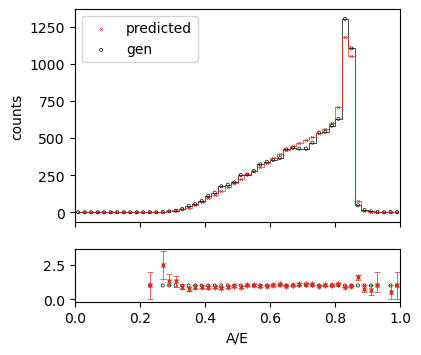

In [45]:
for x in range(output_dims):      
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.5*3/2.5,3.8), gridspec_kw={'height_ratios': [2,0.5]})
    
    ax1.step(all_edges[x], all_counts[x][1], where="mid", color="k", linewidth=0.5)#, linestyle="-.")
    ax1.step(all_edges[x], pred50[x], where="mid", color="#d7301f", linewidth=0.5)
    ax1.scatter(all_edges[x], pred50[x], label="predicted", color="#d7301f", marker="x", s=5, linewidth=0.5)
    ax1.scatter(all_edges[x], all_counts[x][1], label="gen",  color="k",facecolors='none', marker="o", s=5, linewidth=0.5)
    
    ax1.set_xlim(ranges[x])
    # ax1.set_ylim(0, max(all_counts[x][0])*1.1)
    ax1.set_ylabel("counts")
    ax1.set_xticklabels([])
    ax1.legend()
    
    ax2.scatter(all_edges[x], all_counts[x][1]/all_counts[x][1], color="k", marker="o",facecolors="none", s=5, linewidth=0.5)
    ax2.errorbar(
        all_edges[x], pred50[x]/all_counts[x][1],
        xerr=0, yerr=[pred50[x]/all_counts[x][1]- pred16[x]/all_counts[x][1], pred84[x]/all_counts[x][1]-pred50[x]/all_counts[x][1]],
        color="#d7301f", ls="",
        capsize=2,capthick=0.5, marker="x", linewidth=0.5, markersize=np.sqrt(5)
    )

    ax2.set_xlabel(labels[x])
    #ax2.set_ylabel(r"$\frac{\textnormal{predicted}}{\textnormal{gen}}$")
    # ax2.set_ylim((0.9,1.1))
    ax2.set_xlim(ranges[x])
    
    # plt.tight_layout()
    #fig.subplots_adjust(wspace=0.0, hspace=0.1)

(5, 1015500) (2, 1015500) (1, 1015500) (1, 1015500)


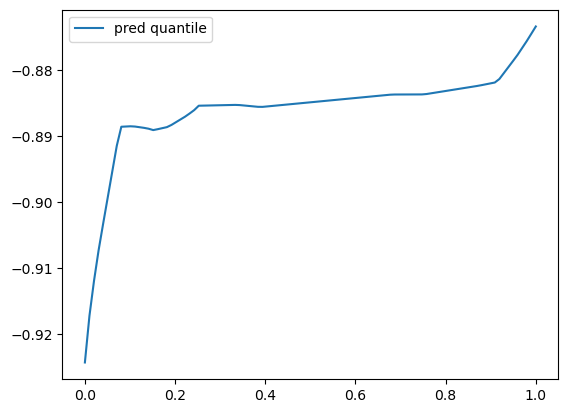

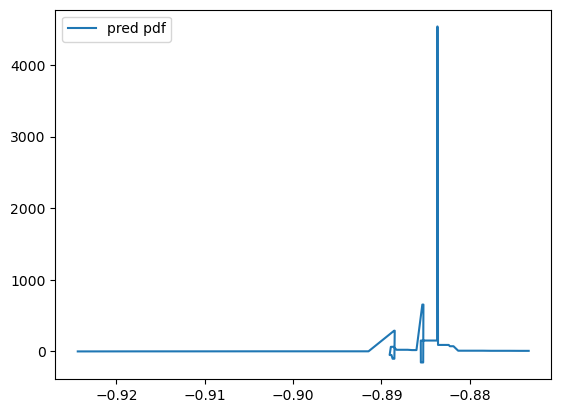

In [84]:
# Generate pdf and cdf for 10,000 quantiles between 0 and 1
quants = tf.cast(np.linspace(0, 1, 100), tf.float32)
cdf, pdf, quantiles = predict_dist(
    model,  # Model object
    quants,    # Quantiles to sample at
    tf.transpose(tf.cast(new_test_in_norm, tf.float32)),  # Input examples
    tf.transpose(tf.cast(new_test_in_norm, tf.float32)).shape[1],  # Number of input examples
    0,  # Current sampling dim
    tf.transpose(tf.cast(new_test_in_norm, tf.float32)).shape[0],  # Input dim
    2, # Output dim
    network_type='no normalizing'
) 

# pdf, cdf, and quantile function for 1st dimension
plt.plot(quantiles, cdf[0, :], label="pred quantile")
# plt.plot(cdf[0, :], quantiles, label="pred cdf")
plt.legend()

plt.figure()
plt.plot(cdf[0, :], pdf[0, :], label="pred pdf")
plt.legend()


In [63]:

# Generate pdf and cdf for 10,000 quantiles between 0 and 1
quants = tf.cast(np.linspace(0, 1, 10), tf.float32)
cdf, pdf, quantiles = predict_dist(
    model,  # Model object
    quants,    # Quantiles to sample at
    tf.transpose(current_test_in),  # Input examples
    tf.transpose(current_test_in).shape[1],  # Number of input examples
    1,  # Current sampling dim
    tf.transpose(current_test_in).shape[0],  # Input dim
    2, # Output dim
    previous_samples=tf.transpose(current_test_in),
    network_type='no normalizing'
) 

# pdf, cdf, and quantile function for 1st dimension
plt.plot(quantiles, cdf[0, :], label="pred quantile")
plt.plot(cdf[0, :], quantiles, label="pred cdf")
plt.legend()

plt.figure()
plt.plot(cdf[0, :], pdf[0, :], label="pred pdf")
plt.legend()


ValueError: in user code:

    File "/Users/williamquinn/Documents/legend/quantileNetwork.py", line 671, in predict_no_normalizing  *
        val = layer(val)
    File "/Users/williamquinn/anaconda3/envs/tfenv/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "/Users/williamquinn/anaconda3/envs/tfenv/lib/python3.11/site-packages/keras/src/engine/input_spec.py", line 280, in assert_input_compatibility
        raise ValueError(

    ValueError: Input 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 9, but received input with shape (8980, 13)
